### 2 Conversion Rate +

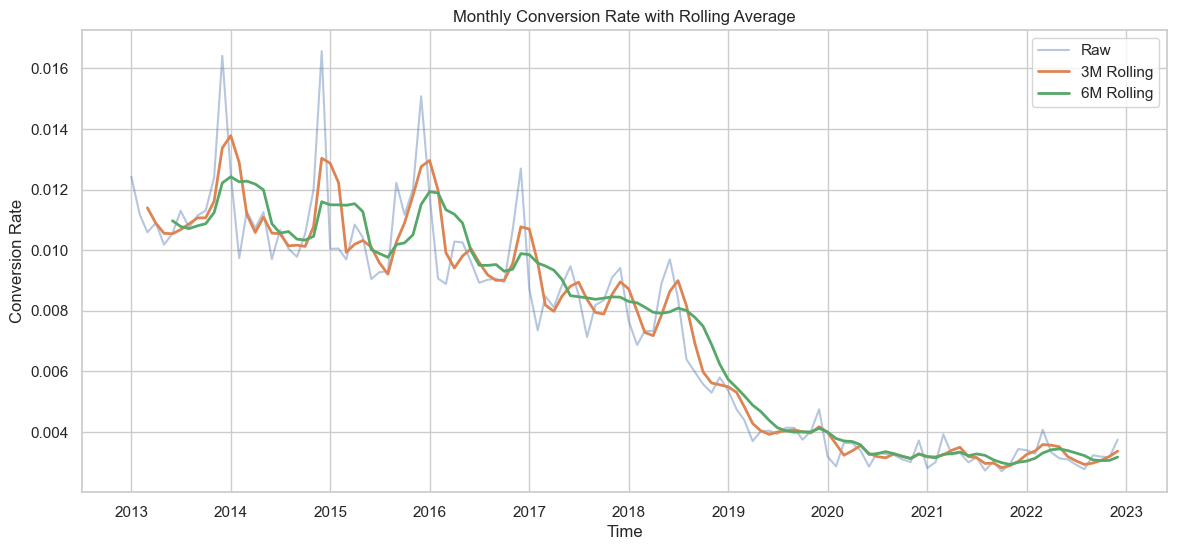

In [2]:
# Monthly conversion + rolling 3M & 6M
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Load data
orders = pd.read_csv("data/orders.csv", parse_dates=["order_date"])
traffic = pd.read_csv("data/web_traffic.csv", parse_dates=["date"])

# Align thời gian
start_date = traffic["date"].min()
orders = orders[orders["order_date"] >= start_date].copy()

# Tạo month
orders["month"] = orders["order_date"].dt.to_period("M")
traffic["month"] = traffic["date"].dt.to_period("M")

# Aggregate
monthly_orders = orders.groupby("month").size().rename("orders")
monthly_sessions = traffic.groupby("month")["sessions"].sum().rename("sessions")

df = pd.concat([monthly_orders, monthly_sessions], axis=1).fillna(0)

# Conversion rate
df["conversion_rate"] = df["orders"] / df["sessions"]

# Rolling
df["cr_3m"] = df["conversion_rate"].rolling(3).mean()
df["cr_6m"] = df["conversion_rate"].rolling(6).mean()

# Convert index sang datetime để plot đẹp
df.index = df.index.to_timestamp()

# Visualization
plt.figure(figsize=(14, 6))

# Raw
plt.plot(df.index, df["conversion_rate"], label="Raw", alpha=0.4)

# Rolling
plt.plot(df.index, df["cr_3m"], label="3M Rolling", linewidth=2)
plt.plot(df.index, df["cr_6m"], label="6M Rolling", linewidth=2)

plt.title("Monthly Conversion Rate with Rolling Average")
plt.xlabel("Time")
plt.ylabel("Conversion Rate")

plt.legend()
plt.show()

Conversion rate = (tổng order 1 tháng) / (session 1 tháng)
- orders.csv và web_traffic.csv không có chung 1 mốc bắt đầu nên ta sẽ phải cắt đi tất cả các order trước 2013-1-1 ( điểm bắt đầu của web_traffic ) để tính conversion_rate 
- sau khi quan sát ta chia ra thành 2 mốc 
    - Trước 2019: 
    raw: biến động lên xuống mạnh mẽ, nhưng khá có tính chu kì, tăng mạnh ở những tháng cuối năm nhưng giảm liên tục đến đầu năm sau đó rồi lại bình ổn đến cuối năm 
    3m và 6m: tương tự có tính biến động chu kì như vậy nhưng đến 2017 có xu hướng đi xuống rõ rệt
    - Sau 2019: cả 3 đường đều giảm theo U-shape
> Như vậy chuyện sụp đổ ở 2019 có lẽ không phải là đột ngột, đó chỉ là hệ quả âm thầm từ 2017-2018

- hơn hết ta thấy conversion rate rất thấp, max 1.6% min 0.4%

### 4 Ngưỡng chịu đựng của khách hàng

#### 4.1 Ngưỡng chịu đựng đối với late delivery

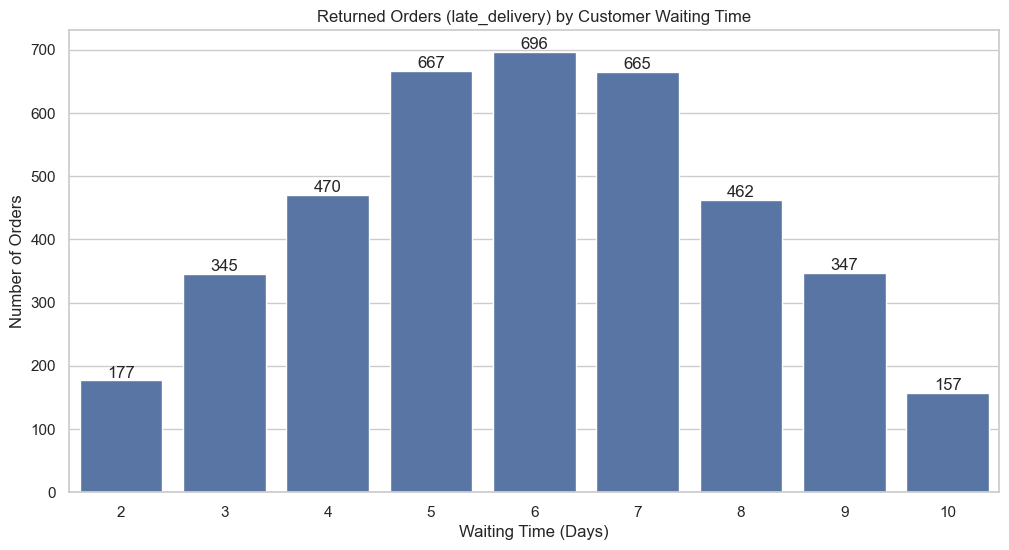

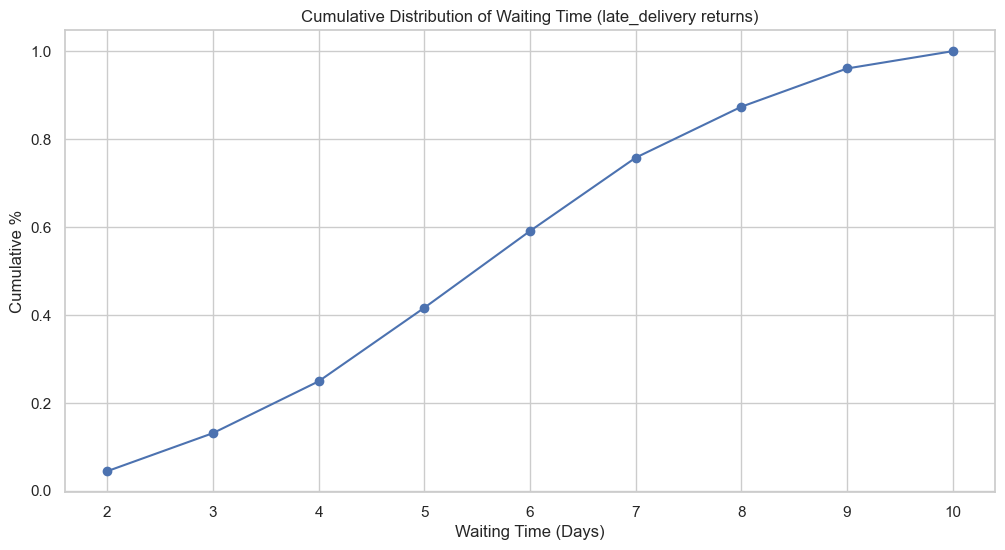

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Load data
orders = pd.read_csv("data/orders.csv", parse_dates=["order_date"])
shipments = pd.read_csv("data/shipments.csv", parse_dates=["ship_date", "delivery_date"])
returns = pd.read_csv("data/returns.csv")

df = orders.merge(shipments, on="order_id", how="inner")
df = df.merge(returns, on="order_id", how="inner")

df = df[
    (df["order_status"] == "returned") &
    (df["return_reason"] == "late_delivery")
].copy()

df["waiting_days"] = (df["delivery_date"] - df["order_date"]).dt.days

# clean data
df = df[df["waiting_days"] >= 0]

waiting_dist = df["waiting_days"].value_counts().sort_index()

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=waiting_dist.index,
    y=waiting_dist.values
)

for i, v in enumerate(waiting_dist.values):
    ax.text(i, v, str(v), ha='center', va='bottom')

plt.title("Returned Orders (late_delivery) by Customer Waiting Time")
plt.xlabel("Waiting Time (Days)")
plt.ylabel("Number of Orders")

plt.show()

cum_dist = waiting_dist.cumsum() / waiting_dist.sum()

plt.figure(figsize=(12,6))

cum_dist.plot(marker='o')

plt.title("Cumulative Distribution of Waiting Time (late_delivery returns)")
plt.xlabel("Waiting Time (Days)")
plt.ylabel("Cumulative %")

plt.show()

Trong bộ dữ liệu chúng ta không có những cột như expect_delivery_date hay các kì vọng tương tự
> Ta sẽ xem như khoảng thời gian khách hàng chịu đựng tính từ *order_date* cho đến *delivery_date*
Như vậy Distribution đối với khoảng thời gian này có hình tam giác với đỉnh là 6.
Nhưng ta nên nhìn vào biểu đồ Cummulative ( ngưỡng tích lũy ) đối với các khách hàng trả lại, ta thấy **50%** khách hàng sẽ trả lại hàng nếu như thời *waiting time* = 5

### 8. Số lượng promotions qua các năm

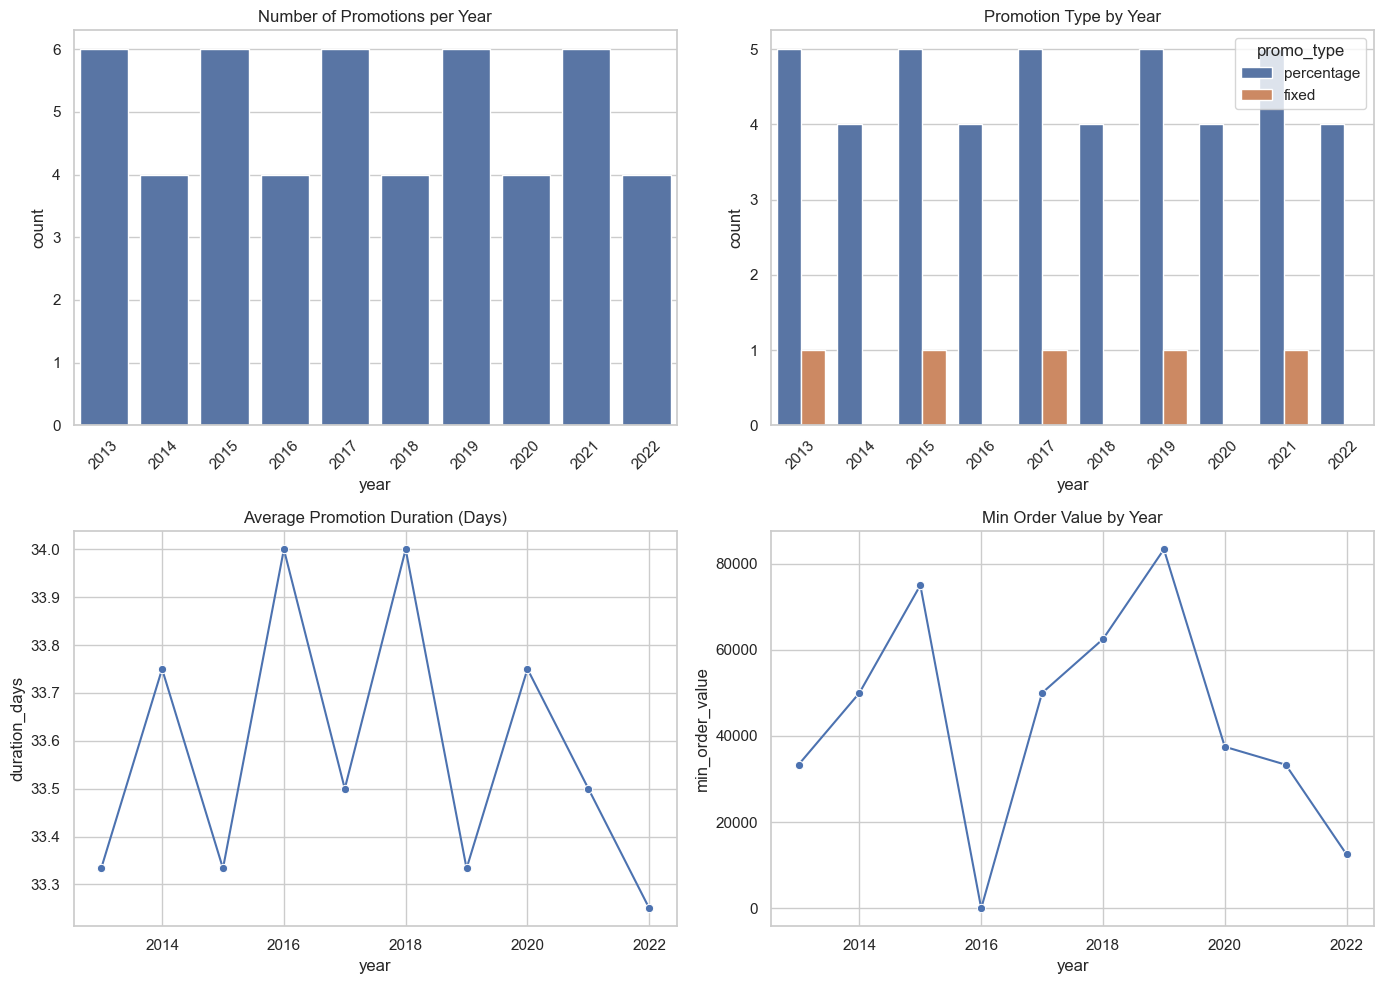

In [10]:
# ===== Promotion Analysis & Visualization =====
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
promo = pd.read_csv('data/promotions.csv')

# Preprocess
promo['start_date'] = pd.to_datetime(promo['start_date'])
promo['end_date'] = pd.to_datetime(promo['end_date'])

promo['year'] = promo['start_date'].dt.year
promo['duration_days'] = (promo['end_date'] - promo['start_date']).dt.days

# Split by type
percent = promo[promo['promo_type'] == 'percentage']
fixed = promo[promo['promo_type'] == 'fixed']

# ===== Set style =====
sns.set_style("whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ===== 1. Campaign count per year =====
sns.countplot(data=promo, x='year', ax=axes[0,0])
axes[0,0].set_title('Number of Promotions per Year')
axes[0,0].tick_params(axis='x', rotation=45)

# ===== 2. Promotion type distribution =====
sns.countplot(data=promo, x='year', hue='promo_type', ax=axes[0,1])
axes[0,1].set_title('Promotion Type by Year')
axes[0,1].tick_params(axis='x', rotation=45)

# ===== 3. Duration trend =====
sns.lineplot(data=promo.groupby('year')['duration_days'].mean().reset_index(),
             x='year', y='duration_days', marker='o', ax=axes[1,0])

axes[1,0].set_title('Average Promotion Duration (Days)')

# ===== 4. Min order value =====
mov = promo.groupby('year')['min_order_value'].mean().reset_index()

sns.lineplot(data=mov, x='year', y='min_order_value', marker='o', ax=axes[1,1])
axes[1,1].set_title('Min Order Value by Year')

# Layout
plt.tight_layout()
plt.show()

Việc nhìn tổng quan promotion theo năm không nói lên được gì nhiều, bởi số lượng là gần như không đổi và có tính chu kỳ, năm chẵn-lẻ

Vì vậy ta sẽ tiến hành xem thử liệu các promotions này có thực sự hiểu quả hay không

C:\Users\nguye\AppData\Local\Temp\ipykernel_22624\2284435937.py:8: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv('data/order_items.csv')


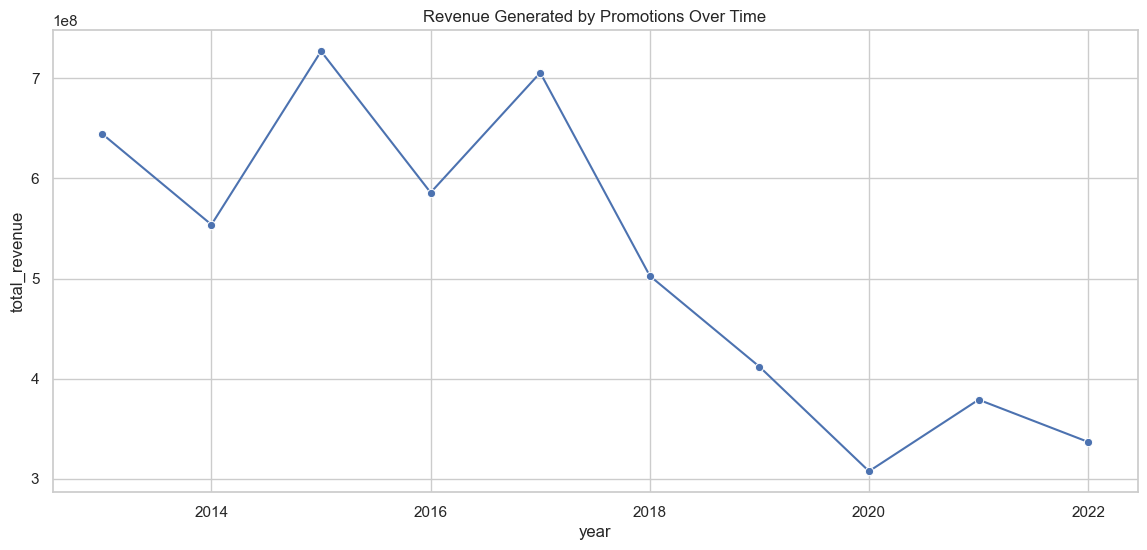

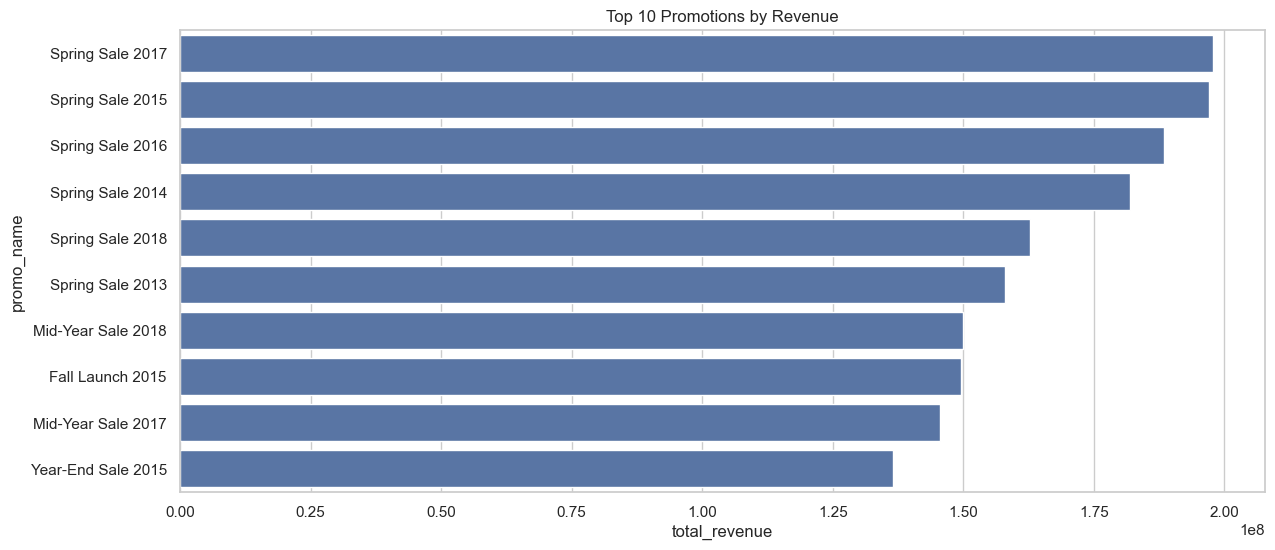

In [12]:
# ===== Promotion Effectiveness Analysis =====
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
promo = pd.read_csv('data/promotions.csv')
order_items = pd.read_csv('data/order_items.csv')
orders = pd.read_csv('data/orders.csv')
payments = pd.read_csv('data/payments.csv')

# ===== Merge =====
df = order_items.merge(promo, on='promo_id', how='left')

# NOTE: include promo_id_2 (stacked promo)
df2 = order_items.merge(promo, left_on='promo_id_2', right_on='promo_id', how='left')

df = pd.concat([df, df2], ignore_index=True)

# Join orders + payments
df = df.merge(orders[['order_id','order_date','order_source']], on='order_id', how='left')
df = df.merge(payments[['order_id','payment_value']], on='order_id', how='left')

# ===== Feature engineering =====
df['year'] = pd.to_datetime(df['order_date']).dt.year

df['gross_value'] = df['quantity'] * df['unit_price']
df['net_value'] = df['gross_value'] - df['discount_amount']

# ===== Aggregate =====
promo_perf = df.groupby(['year','promo_name']).agg(
    total_orders=('order_id','nunique'),
    total_revenue=('payment_value','sum'),
    total_discount=('discount_amount','sum'),
    total_items=('quantity','sum')
).reset_index()

# ===== Visualization =====
sns.set_style("whitegrid")

plt.figure(figsize=(14,6))
sns.lineplot(data=promo_perf.groupby('year')['total_revenue'].sum().reset_index(),
             x='year', y='total_revenue', marker='o')

plt.title('Revenue Generated by Promotions Over Time')
plt.show()


plt.figure(figsize=(14,6))
top_promos = promo_perf.sort_values('total_revenue', ascending=False).head(10)

sns.barplot(data=top_promos, x='total_revenue', y='promo_name')
plt.title('Top 10 Promotions by Revenue')
plt.show()


- Biểu đồ 1 *revenue* thu được từ các promotion:
    - Có xu hướng U-shape chứng tỏ theo thời gian, các promotions đang dần tỏ ra kém hiệu quả
- Biểu đồ 2 các promotions hiệu quả nhất nằm từ 2015-2018

### 9 Cancel orders có tăng nhiều so với các năm trước đó hay không 

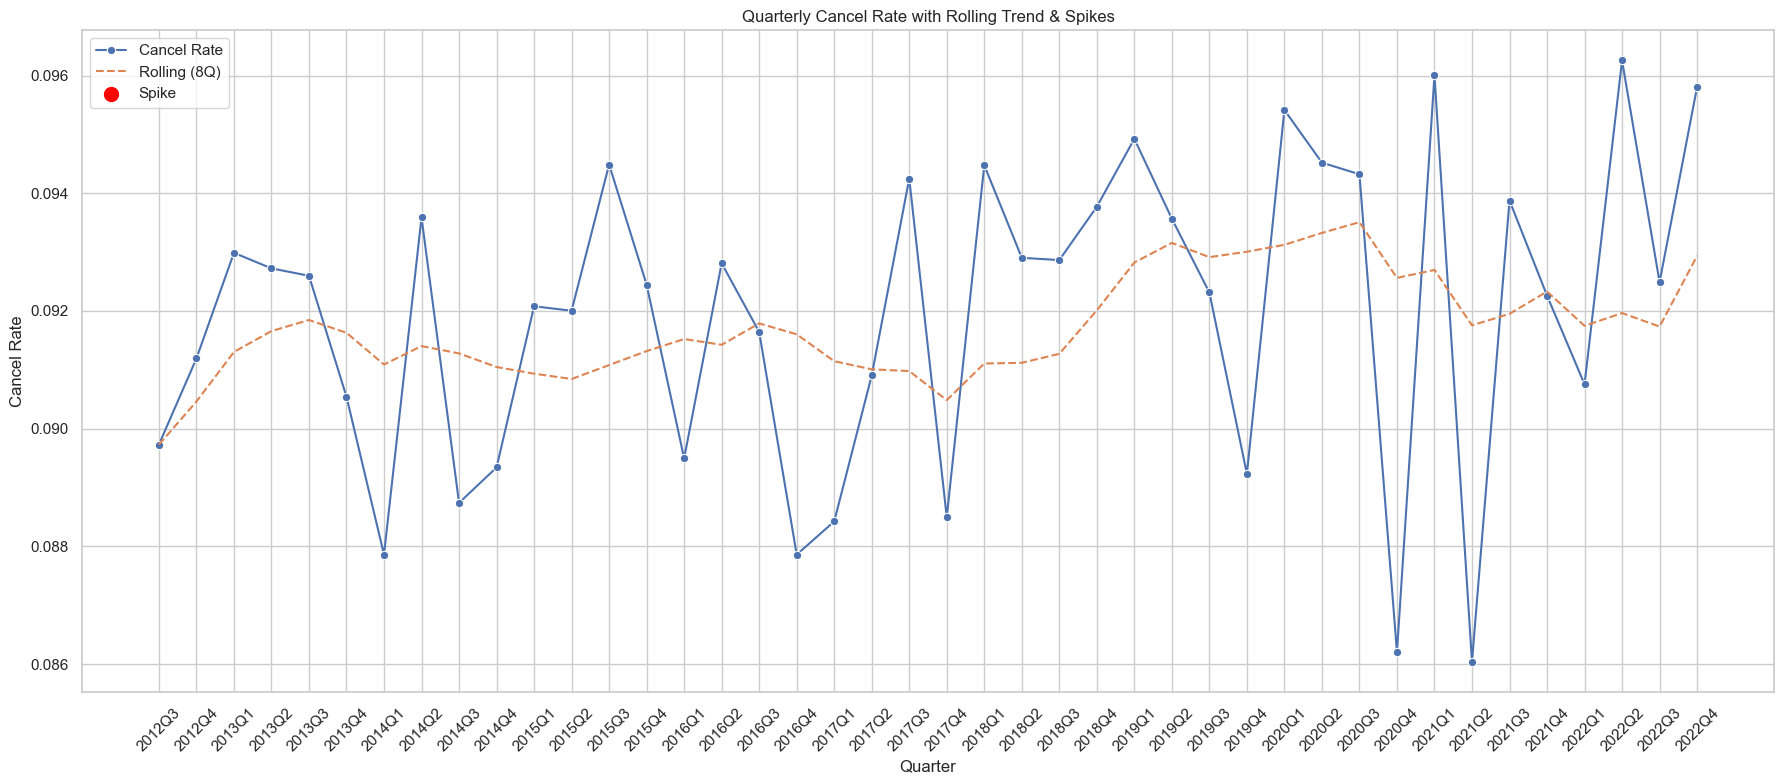

In [17]:
# ===== Cancel Order Analysis - Quarterly + Rolling + Spike =====
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
orders = pd.read_csv('data/orders.csv')

# Parse date
orders['order_date'] = pd.to_datetime(orders['order_date'])

# ===== Create quarter =====
orders['quarter'] = orders['order_date'].dt.to_period('Q')

# ===== Cancel filter =====
cancel_orders = orders[orders['order_status'] == 'cancelled'].copy()

# ===== Aggregate =====
quarterly_cancel = cancel_orders.groupby('quarter').size().rename('cancel_count')
quarterly_total = orders.groupby('quarter').size().rename('total_orders')

quarterly = pd.concat([quarterly_cancel, quarterly_total], axis=1).fillna(0)
quarterly['cancel_rate'] = quarterly['cancel_count'] / quarterly['total_orders']

# Sort index (important)
quarterly = quarterly.sort_index()

# ===== Rolling trend (8 quý) =====
quarterly['cancel_rate_smooth'] = quarterly['cancel_rate'].rolling(window=8, min_periods=1).mean()

# ===== Spike detection =====
quarterly['pct_change'] = quarterly['cancel_rate'].pct_change()

# Define spike threshold (bạn có thể chỉnh)
threshold = 0.3  # tăng >30% là spike
quarterly['spike'] = quarterly['pct_change'] > threshold

# Reset index để plot
quarterly = quarterly.reset_index()
quarterly['quarter_str'] = quarterly['quarter'].astype(str)

# ===== Visualization =====
sns.set_style("whitegrid")
plt.figure(figsize=(18,8))

# Main line
sns.lineplot(data=quarterly, x='quarter_str', y='cancel_rate', marker='o', label='Cancel Rate')

# Rolling line
sns.lineplot(data=quarterly, x='quarter_str', y='cancel_rate_smooth', linestyle='--', label='Rolling (8Q)')

# Highlight spikes
spikes = quarterly[quarterly['spike']]

plt.scatter(spikes['quarter_str'], spikes['cancel_rate'], 
            color='red', s=100, label='Spike')

# Annotate spikes
for i, row in spikes.iterrows():
    plt.text(i, row['cancel_rate'], f"{row['pct_change']:.1%}", color='red')

plt.title('Quarterly Cancel Rate with Rolling Trend & Spikes')
plt.xlabel('Quarter')
plt.ylabel('Cancel Rate')
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

Từ biểu đồ có thể thấy trong tất cả khoảng thời gian doanh nghiệp hoạt động *cancel_rate* luôn ở mức 8.6% đến 9.6%, chúng ta cùng xem số lượng đơn hàng theo từng quý như thế nào ?

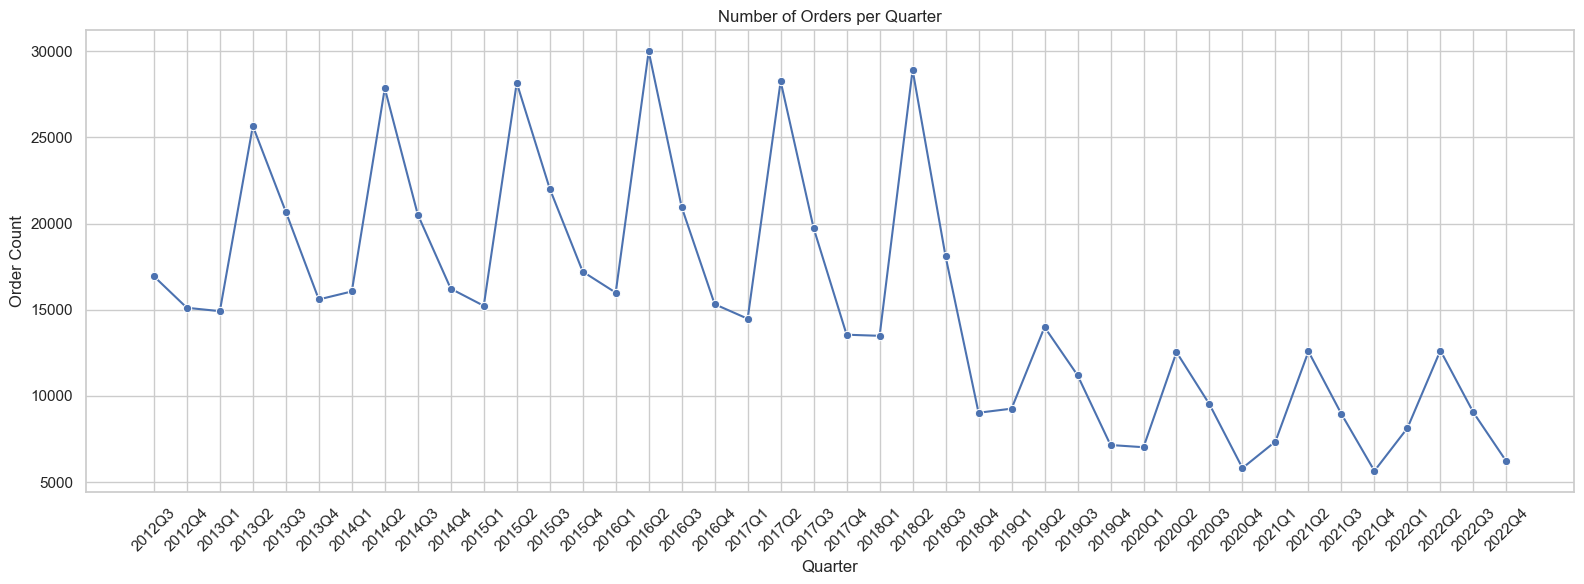

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
orders = pd.read_csv('data/orders.csv')

# Parse date
orders['order_date'] = pd.to_datetime(orders['order_date'])

# Tạo cột quarter
orders['quarter'] = orders['order_date'].dt.to_period('Q')

# Aggregate
quarterly_orders = orders.groupby('quarter').size().reset_index(name='order_count')

# Sort đúng thứ tự thời gian
quarterly_orders = quarterly_orders.sort_values('quarter')
quarterly_orders['quarter_str'] = quarterly_orders['quarter'].astype(str)

# ===== Visualization =====
sns.set_style("whitegrid")
plt.figure(figsize=(16,6))

sns.lineplot(data=quarterly_orders, x='quarter_str', y='order_count', marker='o')

plt.title('Number of Orders per Quarter')
plt.xlabel('Quarter')
plt.ylabel('Order Count')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Từ biểu đồ có thể thấy số lượng order theo quý là rất cao, thấp nhất 5000 cao nhất 30000 nhưng tỉ lệ cancel lại nhảy từ 8.6%-9.6% tức là từ 430-2580 đơn hàng bị cancel -> Một con số không hề nhỏ